<a href="https://colab.research.google.com/github/spirosChv/neuro208/blob/main/practicals/hh_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# @title Make nicer plots -- Execute this cell
def mystyle():
  """
  Create custom plotting style.

  Returns
  -------
  my_style : dict
      Dictionary with matplotlib parameters.

  """
  # color pallette
  style = {
      # Use LaTeX to write all text
      "text.usetex": False,
      "font.family": "DejaVu Sans",
      "font.weight": "bold",
      # Use 16pt font in plots, to match 16pt font in document
      "axes.labelsize": 16,
      "axes.titlesize": 20,
      "font.size": 16,
      # Make the legend/label fonts a little smaller
      "legend.fontsize": 14,
      "xtick.labelsize": 14,
      "ytick.labelsize": 14,
      "axes.linewidth": 2.5,
      "lines.markersize": 10.0,
      "lines.linewidth": 2.5,
      "xtick.major.width": 2.2,
      "ytick.major.width": 2.2,
      "axes.labelweight": "bold",
      "axes.spines.right": False,
      "axes.spines.top": False
  }

  return style


plt.style.use("seaborn-colorblind")
plt.rcParams.update(mystyle())

## Hodgkin-Huxley model for squid giant axon

The differential equation that governs the kinetics of the axonal membrane is:

\begin{equation}
C_m \frac{dV}{dt} = -\bar{\text{g}}_L(V-E_L) - \bar{\text{g}}_{\text{Na}}m^3h(V-E_{\text{Na}}) - \bar{\text{g}}_{\text{K}}n^4(V-E_{\text{K}}) + I_e
\end{equation}

The gating variables (i.e., $m$, $h$, and $n$) are governed by the first order kinetics:

\begin{equation}
\frac{dx}{dt}=\alpha_x(1-x) - \beta_xx
\end{equation}

which has the solution:

\begin{equation}
x(t) = x_\infty(V) - \left( n_\infty(V)-n_0) \right) \text{exp} \left( -\frac{t}{\tau_x(V)}\right)
\end{equation}

where

\begin{align}
n_\infty(V) &= \frac{\alpha_x}{\alpha_x+\beta_x} \\
\tau_x(V) &= \frac{1}{\alpha_x+\beta_x}
\end{align}

- Potassium variable (i.e, $n$)
\begin{align}
\\
\alpha_n(V) &= 0.01\frac{V+55}{1-\text{exp}(-(V+55)/10)} \\
\\
\beta_n(V) &= 0.125 \text{exp}(-(V+65)/80)
\end{align}

- Sodium activation variable (i.e, $m$)
\begin{align}
\\
\alpha_m(V) &= 0.1\frac{V+40}{1-\text{exp}(-(V+40)/10)} \\
\\
\beta_m(V) &= 4 \text{exp}(-(V+65)/18)
\end{align}

- Sodium inactivation variable (i.e, $h$)
\begin{align}
\\
\alpha_h(V) &= 4 \text{exp}(-(V+65)/20) \\
\\
\beta_h(V) &= \frac{1}{\text{exp}(-(V+35)/10)+1}
\end{align}



In [57]:
# Plot the gating variables

v = np.linspace(-100, 50, 10000)

# Potassium variable
alpha_n = 0.01*(v+55)/(1-np.exp(-(v+55)/10))
beta_n = 0.125*np.exp(-(v+65)/80)

ninf = alpha_n/(alpha_n + beta_n)
tau_n = 1/(alpha_n + beta_n)

# Sodium variables
alpha_m = 0.1*(v+40)/(1-np.exp(-(v+40)/10))
beta_m = 4*np.exp(-(v+65)/18)

minf = alpha_n/(alpha_n + beta_n)
tau_m = 1/(alpha_n + beta_n)

alpha_h = 0.07*np.exp(-(v+65)/20)
beta_h = 1/(np.exp(-(v+35)/10)+1)

hinf = alpha_n/(alpha_n + beta_n)
tau_h = 1/(alpha_n + beta_n)

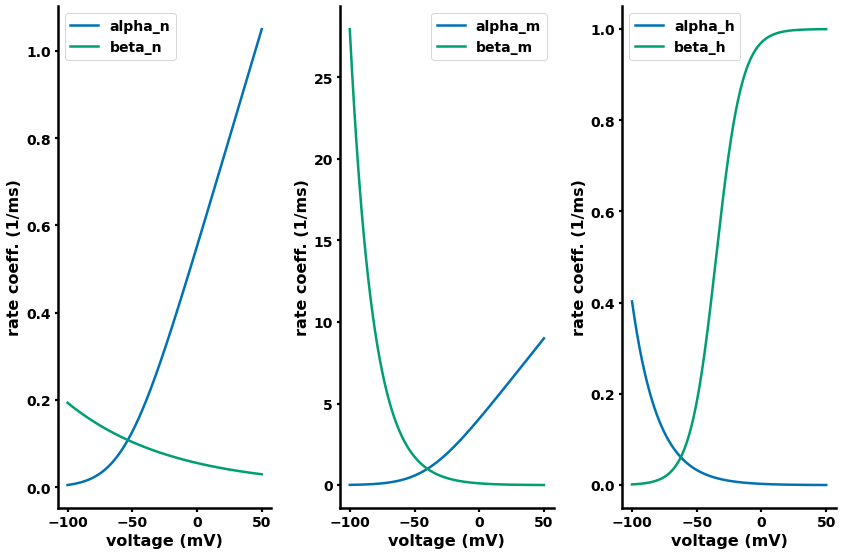

In [58]:
plt.figure(figsize=(12, 8))
plt.subplot(1, 3, 1)
plt.plot(v, alpha_n, label='alpha_n')
plt.plot(v, beta_n, label='beta_n')
plt.xlabel('voltage (mV)')
plt.ylabel('rate coeff. (1/ms)')
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(v, alpha_m, label='alpha_m')
plt.plot(v, beta_m, label='beta_m')
plt.xlabel('voltage (mV)')
plt.ylabel('rate coeff. (1/ms)')
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(v, alpha_h, label='alpha_h')
plt.plot(v, beta_h, label='beta_h')
plt.xlabel('voltage (mV)')
plt.ylabel('rate coeff. (1/ms)')
plt.legend()

plt.tight_layout()
plt.show()

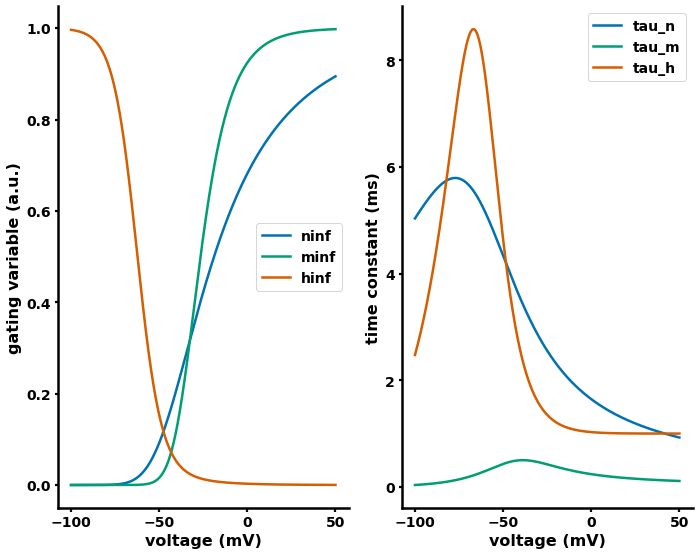

In [59]:
# Calculate the gating variable and their time constants
ninf = alpha_n / (alpha_n + beta_n)
tau_n = 1 / (alpha_n + beta_n)

minf = alpha_m / (alpha_m + beta_m)
tau_m = 1 / (alpha_m + beta_m)

hinf = alpha_h / (alpha_h + beta_h)
tau_h = 1 / (alpha_h + beta_h)


plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(v, ninf**4, label='ninf')
plt.plot(v, minf**3, label='minf')
plt.plot(v, hinf, label='hinf')
plt.xlabel('voltage (mV)')
plt.ylabel('gating variable (a.u.)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(v, tau_n, label='tau_n')
plt.plot(v, tau_m, label='tau_m')
plt.plot(v, tau_h, label='tau_h')
plt.xlabel('voltage (mV)')
plt.ylabel('time constant (ms)')
plt.legend()

plt.tight_layout()
plt.show()

In [63]:
# Simulation parameters
T = 2500  # ms
dt = 0.01  # ms
steps = int(T/dt)
t_vec = np.linspace(0, T, steps+1)

In [64]:
def alpha_m(v):
  return 0.1*(v+40)/(1-np.exp(-(v+40)/10))


def beta_m(v):
  return 4*np.exp(-(v+65)/18)


def alpha_h(v):
  return 0.07*np.exp(-(v+65)/20)


def beta_h(v):
  return 1/(1+np.exp(-(v+35)/10))


def alpha_n(v):
  return 0.01*(v+55)/(1-np.exp(-(v+55)/10))


def beta_n(v):
  return 0.125*np.exp(-(v+65)/80)


def gating(alpha, beta):
  return alpha/(alpha+beta), 1/(alpha+beta)

In [75]:
# Model parameters
cm = 10  # membrane capacitance (nF/mm^2)

gnabar = 1.2  # sodium (Na) maximum conductance (mS/mm^2)
gkbar = 0.36  # potassium (K) maximum conductance (mS/mm^2)
gl = 0.0003  # leak maximum conductance (mS/mm^2)

ena = 50  # sodium (Na) reversal potential (mV)
ek = -77  # potassium (K) reversal potential (mV)
el = -54.387  # leak reversal potential (mV)

m0 = 0.0529
h0 = 0.5961
n0 = 0.3177

In [77]:
cm/gl

33333.333333333336

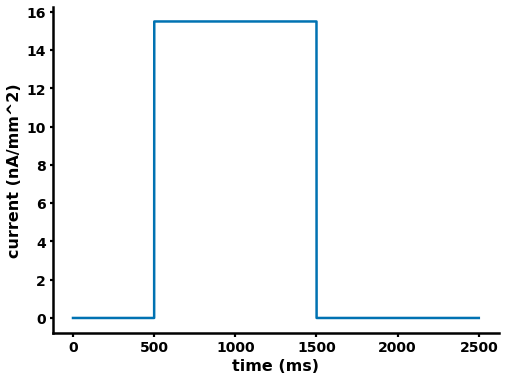

In [76]:
# Create the exteral current
Ie = np.zeros((len(t_vec), ))

t1 = 500  # ms
t2 = t1 + 1000  # ms

n1 = int(t1/dt)
n2 = int(t2/dt)

Ie[n1:n2 + 1] = 15.500  # current amplitude in nA/mm2

plt.figure(figsize=(8, 6))
plt.plot(t_vec, Ie)
plt.xlabel('time (ms)')
plt.ylabel('current (nA/mm^2)')
plt.show()

In [78]:
# Simulation
v = np.zeros((len(t_vec), ))  # Array to store the voltage
v[0] = -65  # initialize voltage at rest

n = np.zeros((len(t_vec), ))  # Activation K+ variable n
n[0] = 0.3177

m = np.zeros((len(t_vec), ))  # Activation Na+ variable m
m[0] = 0.0529

h = np.zeros((len(t_vec), ))  # Inactivation Na+ variable h
h[0] = 0.5961

# Ionic currents
ik = np.zeros((len(t_vec), ))  # K+ current
ina = np.zeros((len(t_vec), ))  # Na+ current
il = np.zeros((len(t_vec), ))  # leakage current

for j in range(steps):
  # Calculate the variables

  ina[j] = gnabar * m[j]**3 * h[j] * (v[j] - ena)
  ik[j] = gkbar * n[j]**4 * (v[j] - ek)
  il[j] = gl * (v[j] - el)

  # Make the updates
  deriv = (-il[j] -ina[j] -ik[j] +Ie[j])/cm
  v[j+1] = v[j] + dt*deriv

  minf, taum = gating(alpha_m(v[j]), beta_m(v[j]))
  deriv_m = (minf-m[j])/taum
  m[j+1] = m[j] + dt*deriv_m

  hinf, tauh = gating(alpha_h(v[j]), beta_h(v[j]))
  deriv_h = (hinf-h[j])/tauh
  h[j+1] = h[j] + dt*deriv_h

  ninf, taun = gating(alpha_n(v[j]), beta_n(v[j]))
  deriv_n = (ninf-n[j])/taun
  n[j+1] = n[j] + dt*deriv_n

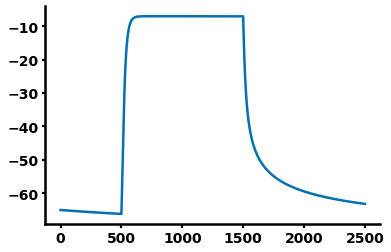

In [79]:
plt.plot(t_vec, v)

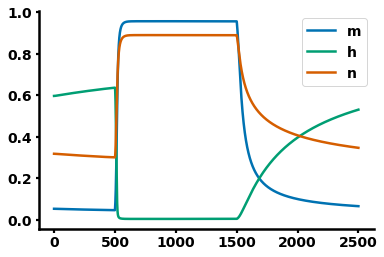

In [80]:
plt.plot(t_vec, m, label="m")
plt.plot(t_vec, h, label="h")
plt.plot(t_vec, n, label="n")
plt.legend()
plt.show()